# Active Matter Zeta Diagnostics, Local CPU Notebook

This notebook performs a local, CPU-only, no-training diagnostic pass over the Polymathic AI / The Well `active_matter` dataset. The goal is to understand which physical structures vary with `zeta`, especially orientation/alignment structure, before running any JEPA training on HPC.

Safety constraints used throughout:
- no model training
- no GPU assumptions
- no full-dataset trajectory cache
- one trajectory processed at a time for summary passes
- incremental CSV/JSON outputs
- labels are used only for stratified diagnostics and visualization

## 1. Setup

In [1]:
from __future__ import annotations

import gc
import json
import math
import random
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Sequence, Tuple

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 120,
    "savefig.dpi": 160,
    "axes.grid": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "image.cmap": "viridis",
})

In [2]:
@dataclass
class LocalConfig:
    data_root: Path = Path("data")
    output_dir: Path = Path("outputs/active_matter_zeta_diagnostics_local")
    split_names: Tuple[str, ...] = ("train", "valid", "test")
    file_patterns: Tuple[str, ...] = ("*.hdf5", "*.h5")
    max_files_per_split: Optional[int] = None
    max_trajectories: Optional[int] = None
    correlation_downsample: int = 4
    summary_flush_every: int = 8
    representative_time_points: Tuple[int, ...] = (0, 20, 40, 60, 80)
    context_chunk_len: int = 4
    target_chunk_len: int = 4
    future_gap: int = 4
    frame_stride: int = 1

CFG = LocalConfig()
DATA_ROOT = CFG.data_root
OUTPUT_DIR = CFG.output_dir
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"
CACHE_DIR = OUTPUT_DIR / "cache"
for directory in (OUTPUT_DIR, FIGURES_DIR, TABLES_DIR, CACHE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print(json.dumps({**asdict(CFG), "data_root": str(DATA_ROOT), "output_dir": str(OUTPUT_DIR)}, indent=2, default=str))

{
  "data_root": "data",
  "output_dir": "outputs/active_matter_zeta_diagnostics_local",
  "split_names": [
    "train",
    "valid",
    "test"
  ],
  "file_patterns": [
    "*.hdf5",
    "*.h5"
  ],
  "max_files_per_split": null,
  "max_trajectories": null,
  "correlation_downsample": 4,
  "summary_flush_every": 8,
  "representative_time_points": [
    0,
    20,
    40,
    60,
    80
  ],
  "context_chunk_len": 4,
  "target_chunk_len": 4,
  "future_gap": 4,
  "frame_stride": 1
}


## 2. Dataset Inspection

The scanner below records file-level metadata without loading the full arrays. It tries common group/dataset names first and falls back to a recursive search when needed.

In [3]:
def safe_scalar(x: Any) -> float:
    if isinstance(x, h5py.Dataset):
        x = x[()]
    arr = np.asarray(x)
    if arr.shape == ():
        return float(arr)
    return float(arr.reshape(-1)[0])


def list_hdf5_files(data_root: Path, split_names: Sequence[str], patterns: Sequence[str], max_files: Optional[int] = None) -> List[Path]:
    files: List[Path] = []
    for split in split_names:
        split_dir = data_root / split
        if not split_dir.exists():
            print(f"Skipping missing split directory: {split_dir}")
            continue
        split_files: List[Path] = []
        for pattern in patterns:
            split_files.extend(sorted(split_dir.glob(pattern)))
        if max_files is not None:
            split_files = split_files[:max_files]
        files.extend(split_files)
    if not files:
        raise FileNotFoundError(f"No HDF5 files found under {data_root.resolve()}")
    return files


def all_dataset_paths(h5: h5py.File) -> List[str]:
    paths: List[str] = []
    def visitor(name: str, obj: Any) -> None:
        if isinstance(obj, h5py.Dataset):
            paths.append(name)
    h5.visititems(visitor)
    return sorted(paths)


def group_names(h5: h5py.File) -> List[str]:
    names: List[str] = []
    def visitor(name: str, obj: Any) -> None:
        if isinstance(obj, h5py.Group):
            names.append(name)
    h5.visititems(visitor)
    return sorted(names)


def find_dataset_key(h5: h5py.File, candidates: Sequence[str], contains: Optional[Sequence[str]] = None) -> str:
    for key in candidates:
        if key in h5 and isinstance(h5[key], h5py.Dataset):
            return key
    paths = all_dataset_paths(h5)
    if contains:
        tokens = [token.lower() for token in contains]
        basename_matches = [p for p in paths if Path(p).name.lower() in tokens]
        if basename_matches:
            return basename_matches[0]
        matches = [p for p in paths if all(token in p.lower() for token in tokens)]
        if matches:
            return matches[0]
    raise KeyError(f"Could not find dataset. Tried candidates={list(candidates)} contains={contains}. Available datasets={paths[:40]}")


def read_optional_scalar(h5: h5py.File, name: str) -> float:
    candidates = [f"scalars/{name}", name]
    for key in candidates:
        if key in h5:
            return safe_scalar(h5[key])
    if name in h5.attrs:
        return safe_scalar(h5.attrs[name])
    raise KeyError(f"Could not find scalar '{name}' in datasets or attributes")


def infer_num_trajectories(shape: Tuple[int, ...], expected_tail_ndim: int) -> int:
    if len(shape) == expected_tail_ndim:
        return 1
    if len(shape) == expected_tail_ndim + 1:
        return int(shape[0])
    raise ValueError(f"Unexpected shape {shape} for expected tail ndim {expected_tail_ndim}")


def scan_file_metadata(path: Path) -> Dict[str, Any]:
    with h5py.File(path, "r") as h5:
        c_key = find_dataset_key(h5, ["t0_fields/concentration", "fields/concentration", "concentration"], ["concentration"])
        v_key = find_dataset_key(h5, ["t1_fields/velocity", "fields/velocity", "velocity"], ["velocity"])
        d_key = find_dataset_key(h5, ["t2_fields/D", "fields/D", "D"], ["d"])
        e_key = find_dataset_key(h5, ["t2_fields/E", "fields/E", "E"], ["e"])
        c_shape = tuple(h5[c_key].shape)
        n_traj = infer_num_trajectories(c_shape, expected_tail_ndim=3)
        time_steps, height, width = c_shape[-3], c_shape[-2], c_shape[-1]
        split = path.parent.name
        return {
            "split": split,
            "file_path": str(path),
            "file_name": path.name,
            "num_trajectories": n_traj,
            "time_steps": int(time_steps),
            "height": int(height),
            "width": int(width),
            "concentration_key": c_key,
            "velocity_key": v_key,
            "D_key": d_key,
            "E_key": e_key,
            "groups": ";".join(group_names(h5)),
            "datasets": ";".join(all_dataset_paths(h5)),
            "alpha": read_optional_scalar(h5, "alpha"),
            "zeta": read_optional_scalar(h5, "zeta"),
        }

In [4]:
hdf5_files = list_hdf5_files(DATA_ROOT, CFG.split_names, CFG.file_patterns, CFG.max_files_per_split)
metadata_rows = [scan_file_metadata(path) for path in tqdm(hdf5_files, desc="Scanning file metadata")]
metadata_df = pd.DataFrame(metadata_rows)
metadata_path = TABLES_DIR / "dataset_metadata.csv"
metadata_df.to_csv(metadata_path, index=False)

summary = {
    "num_files": int(len(metadata_df)),
    "splits": metadata_df.groupby("split").size().to_dict(),
    "total_trajectories": int(metadata_df["num_trajectories"].sum()),
    "time_steps_unique": sorted(metadata_df["time_steps"].unique().tolist()),
    "spatial_resolutions": sorted({f"{h}x{w}" for h, w in zip(metadata_df["height"], metadata_df["width"])}),
    "alpha_values": sorted(metadata_df["alpha"].unique().tolist()),
    "zeta_values": sorted(metadata_df["zeta"].unique().tolist()),
}
print(json.dumps(summary, indent=2))
print(f"Saved metadata table to {metadata_path}")
metadata_df.head()

Scanning file metadata:   0%|          | 0/82 [00:00<?, ?it/s]

{
  "num_files": 82,
  "splits": {
    "test": 21,
    "train": 45,
    "valid": 16
  },
  "total_trajectories": 225,
  "time_steps_unique": [
    81
  ],
  "spatial_resolutions": [
    "256x256"
  ],
  "alpha_values": [
    -5.0,
    -4.0,
    -3.0,
    -2.0,
    -1.0
  ],
  "zeta_values": [
    1.0,
    3.0,
    5.0,
    7.0,
    9.0,
    11.0,
    13.0,
    15.0,
    17.0
  ]
}
Saved metadata table to outputs/active_matter_zeta_diagnostics_local/tables/dataset_metadata.csv


,split,file_path,file_name,num_trajectories,time_steps,height,width,concentration_key,velocity_key,D_key,E_key,groups,datasets,alpha,zeta
0,train,data/train/active_matter_L_10.0_zeta_1.0_alpha...,active_matter_L_10.0_zeta_1.0_alpha_-1.0.hdf5,3,81,256,256,t0_fields/concentration,t1_fields/velocity,t2_fields/D,t2_fields/E,boundary_conditions;boundary_conditions/x_peri...,boundary_conditions/x_periodic/mask;boundary_c...,-1.0,1.0
1,train,data/train/active_matter_L_10.0_zeta_1.0_alpha...,active_matter_L_10.0_zeta_1.0_alpha_-2.0.hdf5,4,81,256,256,t0_fields/concentration,t1_fields/velocity,t2_fields/D,t2_fields/E,boundary_conditions;boundary_conditions/x_peri...,boundary_conditions/x_periodic/mask;boundary_c...,-2.0,1.0
2,train,data/train/active_matter_L_10.0_zeta_1.0_alpha...,active_matter_L_10.0_zeta_1.0_alpha_-3.0.hdf5,3,81,256,256,t0_fields/concentration,t1_fields/velocity,t2_fields/D,t2_fields/E,boundary_conditions;boundary_conditions/x_peri...,boundary_conditions/x_periodic/mask;boundary_c...,-3.0,1.0
3,train,data/train/active_matter_L_10.0_zeta_1.0_alpha...,active_matter_L_10.0_zeta_1.0_alpha_-4.0.hdf5,4,81,256,256,t0_fields/concentration,t1_fields/velocity,t2_fields/D,t2_fields/E,boundary_conditions;boundary_conditions/x_peri...,boundary_conditions/x_periodic/mask;boundary_c...,-4.0,1.0
4,train,data/train/active_matter_L_10.0_zeta_1.0_alpha...,active_matter_L_10.0_zeta_1.0_alpha_-5.0.hdf5,5,81,256,256,t0_fields/concentration,t1_fields/velocity,t2_fields/D,t2_fields/E,boundary_conditions;boundary_conditions/x_peri...,boundary_conditions/x_periodic/mask;boundary_c...,-5.0,1.0


## 3. Canonical Loader Utilities

The loader returns one trajectory at a time and normalizes shape conventions to:
- `concentration`: `[T, H, W]`
- `velocity`: `[T, H, W, 2]`
- `D`: `[T, H, W, 2, 2]`
- `E`: `[T, H, W, 2, 2]`

In [5]:
def _read_traj_dataset(h5: h5py.File, key: str, traj_idx: int, expected_tail_ndim: int) -> np.ndarray:
    ds = h5[key]
    if ds.ndim == expected_tail_ndim:
        if traj_idx != 0:
            raise IndexError(f"Dataset {key} has no trajectory axis, so traj_idx must be 0")
        arr = ds[()]
    elif ds.ndim == expected_tail_ndim + 1:
        if traj_idx >= ds.shape[0]:
            raise IndexError(f"traj_idx={traj_idx} out of range for {key} with {ds.shape[0]} trajectories")
        arr = ds[traj_idx]
    else:
        raise ValueError(f"Unexpected dataset shape for {key}: {ds.shape}")
    return np.asarray(arr, dtype=np.float32)


def load_active_matter_trajectory(path: Path, traj_idx: int = 0) -> Dict[str, Any]:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    with h5py.File(path, "r") as h5:
        c_key = find_dataset_key(h5, ["t0_fields/concentration", "fields/concentration", "concentration"], ["concentration"])
        v_key = find_dataset_key(h5, ["t1_fields/velocity", "fields/velocity", "velocity"], ["velocity"])
        d_key = find_dataset_key(h5, ["t2_fields/D", "fields/D", "D"], ["d"])
        e_key = find_dataset_key(h5, ["t2_fields/E", "fields/E", "E"], ["e"])
        concentration = _read_traj_dataset(h5, c_key, traj_idx, expected_tail_ndim=3)
        velocity = _read_traj_dataset(h5, v_key, traj_idx, expected_tail_ndim=4)
        D = _read_traj_dataset(h5, d_key, traj_idx, expected_tail_ndim=5)
        E = _read_traj_dataset(h5, e_key, traj_idx, expected_tail_ndim=5)
        alpha = read_optional_scalar(h5, "alpha")
        zeta = read_optional_scalar(h5, "zeta")
    assert concentration.ndim == 3, f"concentration must be [T,H,W], got {concentration.shape}"
    assert velocity.ndim == 4 and velocity.shape[-1] == 2, f"velocity must be [T,H,W,2], got {velocity.shape}"
    assert D.ndim == 5 and D.shape[-2:] == (2, 2), f"D must be [T,H,W,2,2], got {D.shape}"
    assert E.ndim == 5 and E.shape[-2:] == (2, 2), f"E must be [T,H,W,2,2], got {E.shape}"
    assert concentration.shape[:3] == velocity.shape[:3] == D.shape[:3] == E.shape[:3], "field shapes disagree"
    return {
        "concentration": concentration,
        "velocity": velocity,
        "D": D,
        "E": E,
        "alpha": float(alpha),
        "zeta": float(zeta),
        "file_path": str(path),
        "traj_idx": int(traj_idx),
    }


def stack_11_channels(sample: Dict[str, Any]) -> np.ndarray:
    c = sample["concentration"]
    v = sample["velocity"]
    D = sample["D"]
    E = sample["E"]
    channels = [
        c[..., None],
        v[..., 0:1], v[..., 1:2],
        D[..., 0, 0, None], D[..., 0, 1, None], D[..., 1, 0, None], D[..., 1, 1, None],
        E[..., 0, 0, None], E[..., 0, 1, None], E[..., 1, 0, None], E[..., 1, 1, None],
    ]
    out = np.concatenate(channels, axis=-1).astype(np.float32, copy=False)
    assert out.ndim == 4 and out.shape[-1] == 11, f"Expected [T,H,W,11], got {out.shape}"
    return out

example_sample = load_active_matter_trajectory(Path(metadata_df.iloc[0]["file_path"]), traj_idx=0)
print({k: (v.shape if isinstance(v, np.ndarray) else v) for k, v in example_sample.items() if k in ["concentration", "velocity", "D", "E", "alpha", "zeta"]})
print("stacked 11-channel shape:", stack_11_channels(example_sample).shape)

{'concentration': (81, 256, 256), 'velocity': (81, 256, 256, 2), 'D': (81, 256, 256, 2, 2), 'E': (81, 256, 256, 2, 2), 'alpha': -1.0, 'zeta': 1.0}
stacked 11-channel shape: (81, 256, 256, 11)


## 4. Physical Consistency Checks

These checks are intentionally lightweight and operate on a small representative subset by default. They compare tensor symmetry, trace, finite values, and basic field statistics.

In [6]:
def finite_stats(name: str, arr: np.ndarray) -> Dict[str, Any]:
    finite = np.isfinite(arr)
    vals = arr[finite]
    return {
        "field": name,
        "finite_fraction": float(finite.mean()),
        "nan_count": int(np.isnan(arr).sum()),
        "inf_count": int(np.isinf(arr).sum()),
        "min": float(vals.min()) if vals.size else np.nan,
        "max": float(vals.max()) if vals.size else np.nan,
        "mean": float(vals.mean()) if vals.size else np.nan,
        "std": float(vals.std()) if vals.size else np.nan,
    }


def tensor_consistency_stats(name: str, tensor: np.ndarray) -> List[Dict[str, Any]]:
    sym_err = tensor[..., 0, 1] - tensor[..., 1, 0]
    trace = tensor[..., 0, 0] + tensor[..., 1, 1]
    rows = []
    rows.append({"field": name, "check": "offdiag_symmetry_abs_mean", "value": float(np.mean(np.abs(sym_err)))})
    rows.append({"field": name, "check": "offdiag_symmetry_abs_max", "value": float(np.max(np.abs(sym_err)))})
    rows.append({"field": name, "check": "trace_abs_mean", "value": float(np.mean(np.abs(trace)))})
    rows.append({"field": name, "check": "trace_abs_max", "value": float(np.max(np.abs(trace)))})
    return rows

consistency_rows: List[Dict[str, Any]] = []
stat_rows: List[Dict[str, Any]] = []
check_paths = metadata_df.sort_values(["zeta", "alpha"]).head(min(6, len(metadata_df)))["file_path"].tolist()
for path in tqdm(check_paths, desc="Physical checks"):
    sample = load_active_matter_trajectory(Path(path), 0)
    for field in ["concentration", "velocity", "D", "E"]:
        row = finite_stats(field, sample[field])
        row.update({"file_path": path, "alpha": sample["alpha"], "zeta": sample["zeta"]})
        stat_rows.append(row)
    for tensor_name in ["D", "E"]:
        for row in tensor_consistency_stats(tensor_name, sample[tensor_name]):
            row.update({"file_path": path, "alpha": sample["alpha"], "zeta": sample["zeta"]})
            consistency_rows.append(row)
    del sample
    gc.collect()

field_stats_df = pd.DataFrame(stat_rows)
consistency_df = pd.DataFrame(consistency_rows)
field_stats_df.to_csv(TABLES_DIR / "field_finite_stats_sample.csv", index=False)
consistency_df.to_csv(TABLES_DIR / "tensor_consistency_checks_sample.csv", index=False)
print("Saved physical consistency tables.")
consistency_df.groupby(["field", "check"])["value"].describe()

Physical checks:   0%|          | 0/6 [00:00<?, ?it/s]

Saved physical consistency tables.


count      mean           std       min  \
field check                                                                
D     offdiag_symmetry_abs_max     6.0  0.000000  0.000000e+00  0.000000   
      offdiag_symmetry_abs_mean    6.0  0.000000  0.000000e+00  0.000000   
      trace_abs_max                6.0  1.036131  4.479204e-03  1.033631   
      trace_abs_mean               6.0  1.000000  3.025584e-07  1.000000   
E     offdiag_symmetry_abs_max     6.0  0.000000  0.000000e+00  0.000000   
      offdiag_symmetry_abs_mean    6.0  0.000000  0.000000e+00  0.000000   
      trace_abs_max                6.0  0.000000  0.000000e+00  0.000000   
      trace_abs_mean               6.0  0.000000  0.000000e+00  0.000000   

                                      25%       50%       75%       max  
field check                                                              
D     offdiag_symmetry_abs_max   0.000000  0.000000  0.000000  0.000000  
      offdiag_symmetry_abs_mean  0.000000  0.000000  0.000000  0.000000  
      trace_abs_max              1.033631  1.033631  1.036589  1.044688  
      trace_abs_mean             1.000000  1.000000  1.000000  1.000001  
E     offdiag_symmetry_abs_max   0.000000  0.000000  0.000000  0.000000  
      offdiag_symmetry_abs_mean  0.000000  0.000000  0.000000  0.000000  
      trace_abs_max              0.000000  0.000000  0.000000  0.000000  
      trace_abs_mean             0.000000  0.000000  0.000000  0.000000

## 5. Local-Safe Zeta Diagnostics

### 5a. Nematic-order proxy

For stability and speed, this notebook uses the mean Frobenius norm of the orientation tensor `E` per frame:

`E_frob(t) = mean_xy sqrt(sum_ij E_ij(t, x, y)^2)`

This is not a full nematic-order parameter, but it is a robust scalar proxy for orientation-tensor magnitude/alignment strength.

### 5b. Spatial correlation-length proxy

For each frame, we convert `E` to the scalar Frobenius-norm map, optionally downsample it, subtract its mean, and compute an FFT-based autocorrelation. We then radially average the autocorrelation and estimate a correlation length as the first radius where the normalized radial autocorrelation falls below `1/e`. This avoids all-pairs distances and keeps memory bounded.

### 5c. Cheap gradient proxy

As an additional texture statistic, we compute the mean spatial gradient magnitude of the same `E` Frobenius map.

In [7]:
def e_frobenius_map(E: np.ndarray) -> np.ndarray:
    return np.sqrt(np.sum(E * E, axis=(-2, -1))).astype(np.float32, copy=False)


def nematic_order_proxy_timeseries(E: np.ndarray) -> np.ndarray:
    return e_frobenius_map(E).mean(axis=(1, 2))


def mean_gradient_magnitude_timeseries(E: np.ndarray) -> np.ndarray:
    fmap = e_frobenius_map(E)
    out = np.empty(fmap.shape[0], dtype=np.float32)
    for t in range(fmap.shape[0]):
        gy, gx = np.gradient(fmap[t])
        out[t] = np.sqrt(gx * gx + gy * gy).mean()
    return out


def _radial_bins(height: int, width: int) -> np.ndarray:
    y = np.arange(height) - height // 2
    x = np.arange(width) - width // 2
    yy, xx = np.meshgrid(y, x, indexing="ij")
    return np.sqrt(xx * xx + yy * yy).astype(np.int32)


def radial_average(image: np.ndarray) -> np.ndarray:
    r = _radial_bins(*image.shape)
    numerator = np.bincount(r.ravel(), weights=image.ravel())
    denominator = np.bincount(r.ravel())
    return numerator / np.maximum(denominator, 1)


def correlation_length_frame(scalar_map: np.ndarray, downsample: int = 4) -> float:
    if downsample > 1:
        scalar_map = scalar_map[::downsample, ::downsample]
    arr = np.asarray(scalar_map, dtype=np.float32)
    arr = arr - float(arr.mean())
    var = float(np.mean(arr * arr))
    if not np.isfinite(var) or var <= 1e-12:
        return 0.0
    fft = np.fft.rfftn(arr)
    ac = np.fft.irfftn(fft * np.conj(fft), s=arr.shape).real
    ac = np.fft.fftshift(ac)
    ac = ac / np.max(ac)
    radial = radial_average(ac)
    if radial.size <= 1:
        return 0.0
    threshold = math.exp(-1.0)
    below = np.where(radial[1:] <= threshold)[0]
    if below.size == 0:
        radius = float(len(radial) - 1)
    else:
        radius = float(below[0] + 1)
    return radius * float(downsample)


def correlation_length_timeseries(E: np.ndarray, downsample: int = 4) -> np.ndarray:
    fmap = e_frobenius_map(E)
    out = np.empty(fmap.shape[0], dtype=np.float32)
    for t in range(fmap.shape[0]):
        out[t] = correlation_length_frame(fmap[t], downsample=downsample)
    return out

sample_metrics = {
    "nematic_proxy_shape": nematic_order_proxy_timeseries(example_sample["E"]).shape,
    "corr_length_first_frame": correlation_length_frame(e_frobenius_map(example_sample["E"])[0], CFG.correlation_downsample),
    "gradient_proxy_shape": mean_gradient_magnitude_timeseries(example_sample["E"]).shape,
}
print(sample_metrics)

{'nematic_proxy_shape': (81,), 'corr_length_first_frame': 8.0, 'gradient_proxy_shape': (81,)}


## 6. Low-Zeta vs High-Zeta Visual Comparison

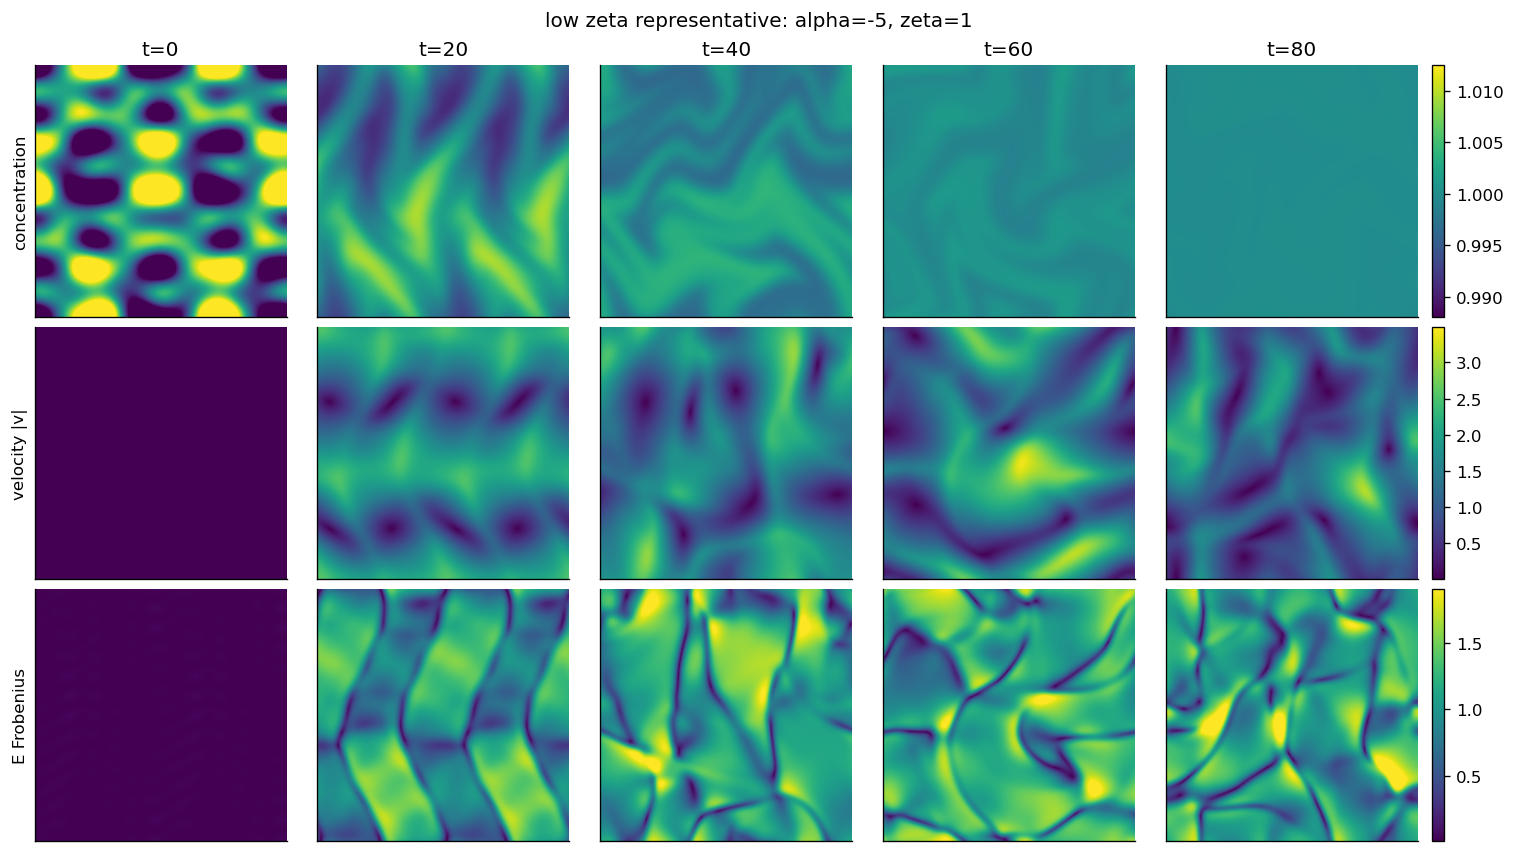

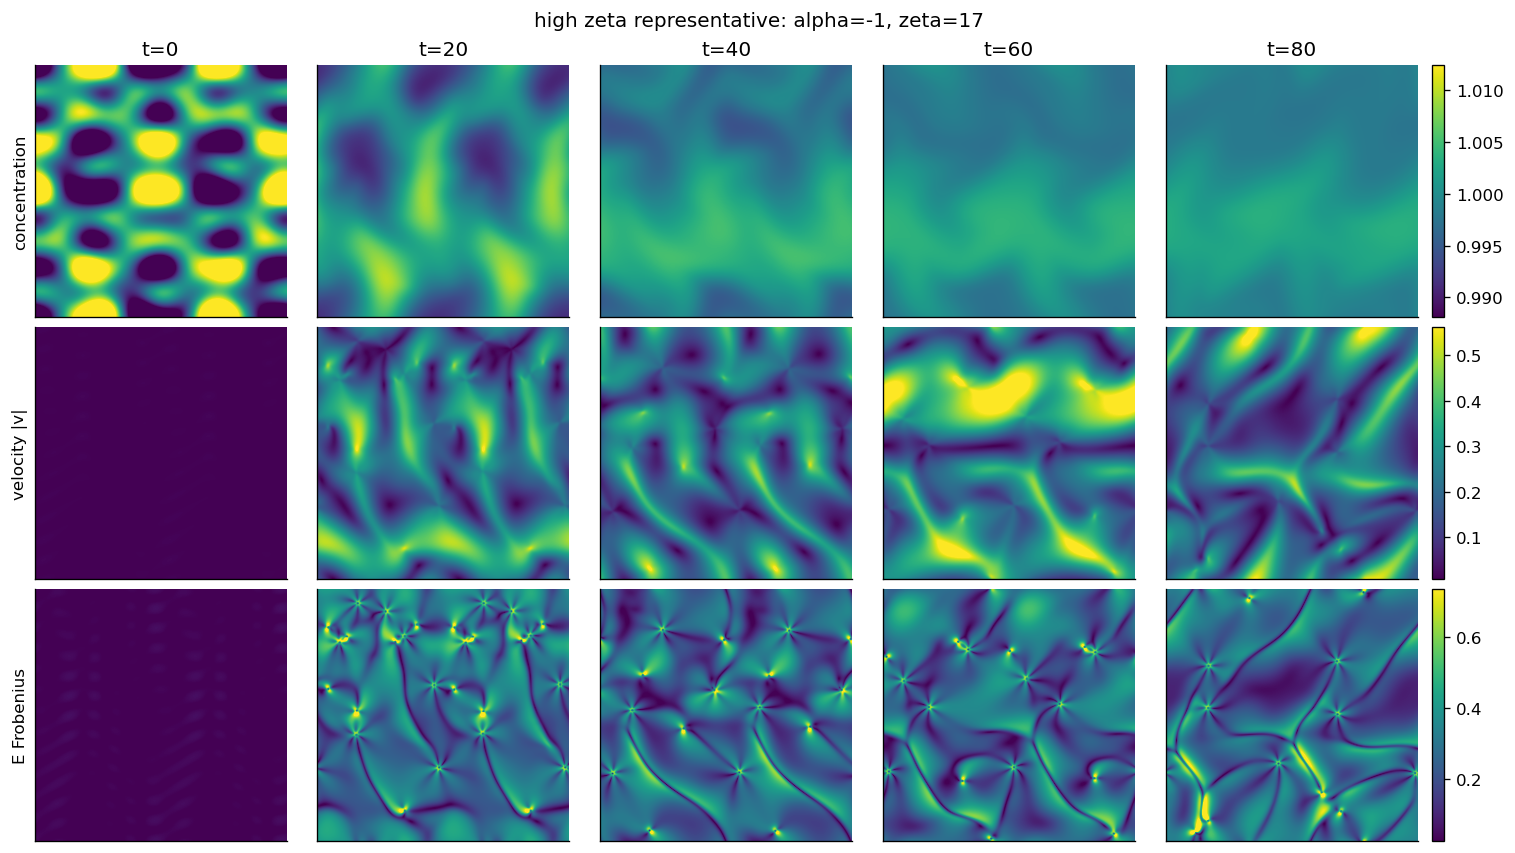

In [8]:
def representative_file_rows(metadata: pd.DataFrame) -> Tuple[pd.Series, pd.Series]:
    ordered = metadata.sort_values(["zeta", "alpha", "file_path"]).reset_index(drop=True)
    return ordered.iloc[0], ordered.iloc[-1]


def velocity_magnitude(v: np.ndarray) -> np.ndarray:
    return np.sqrt(np.sum(v * v, axis=-1))


def plot_representative_trajectory(sample: Dict[str, Any], label: str, time_points: Sequence[int], out_path: Path) -> None:
    T = sample["concentration"].shape[0]
    time_points = [int(np.clip(t, 0, T - 1)) for t in time_points]
    e_scalar = e_frobenius_map(sample["E"])
    vmag = velocity_magnitude(sample["velocity"])
    fields = [("concentration", sample["concentration"]), ("velocity |v|", vmag), ("E Frobenius", e_scalar)]
    fig, axes = plt.subplots(len(fields), len(time_points), figsize=(2.5 * len(time_points), 7.0), constrained_layout=True)
    for row, (field_name, arr) in enumerate(fields):
        vmin, vmax = np.percentile(arr, [1, 99])
        for col, t in enumerate(time_points):
            ax = axes[row, col]
            im = ax.imshow(arr[t], vmin=vmin, vmax=vmax)
            ax.set_xticks([]); ax.set_yticks([])
            if row == 0:
                ax.set_title(f"t={t}")
            if col == 0:
                ax.set_ylabel(field_name)
        fig.colorbar(im, ax=axes[row, :], fraction=0.018, pad=0.01)
    fig.suptitle(f"{label}: alpha={sample['alpha']:.3g}, zeta={sample['zeta']:.3g}")
    fig.savefig(out_path, bbox_inches="tight")
    plt.show()

low_row, high_row = representative_file_rows(metadata_df)
low_sample = load_active_matter_trajectory(Path(low_row["file_path"]), 0)
high_sample = load_active_matter_trajectory(Path(high_row["file_path"]), 0)
plot_representative_trajectory(low_sample, "low zeta representative", CFG.representative_time_points, FIGURES_DIR / "low_zeta_representative_fields.png")
plot_representative_trajectory(high_sample, "high zeta representative", CFG.representative_time_points, FIGURES_DIR / "high_zeta_representative_fields.png")

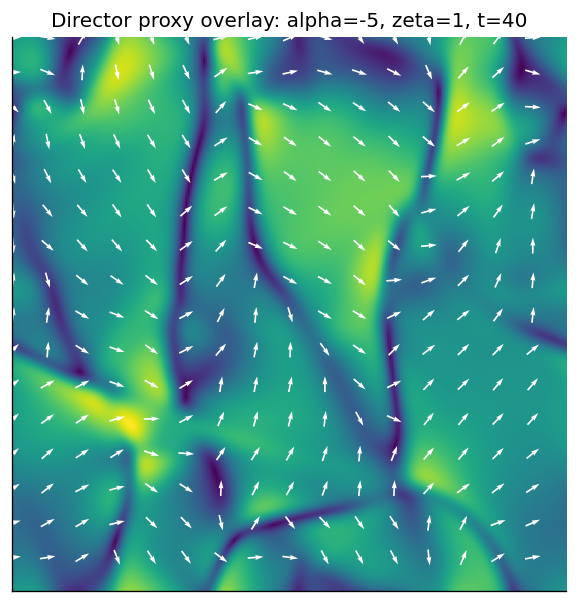

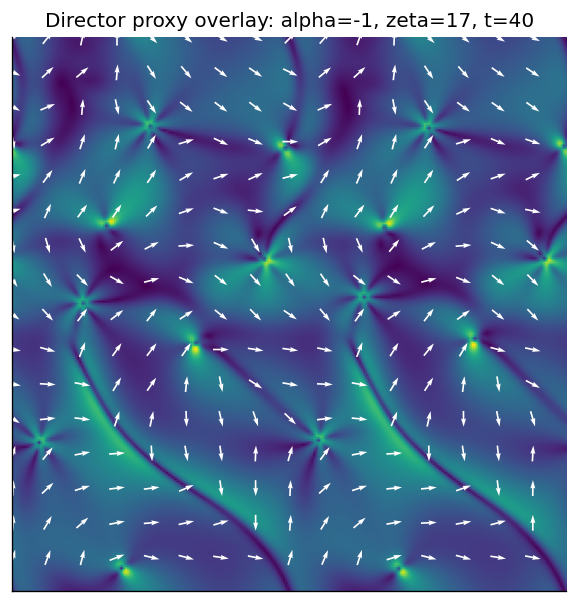

68453

In [9]:
def director_angle_from_E(E_frame: np.ndarray) -> np.ndarray:
    qxx = E_frame[..., 0, 0]
    qxy = 0.5 * (E_frame[..., 0, 1] + E_frame[..., 1, 0])
    qyy = E_frame[..., 1, 1]
    return 0.5 * np.arctan2(2.0 * qxy, qxx - qyy)


def plot_director_overlay(sample: Dict[str, Any], t: int, out_path: Path, step: int = 16) -> None:
    E = sample["E"][t]
    scalar = e_frobenius_map(sample["E"])[t]
    theta = director_angle_from_E(E)
    yy, xx = np.mgrid[0:scalar.shape[0]:step, 0:scalar.shape[1]:step]
    u = np.cos(theta[::step, ::step])
    v = np.sin(theta[::step, ::step])
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(scalar)
    ax.quiver(xx, yy, u, v, color="white", pivot="middle", scale=35, width=0.003)
    ax.set_title(f"Director proxy overlay: alpha={sample['alpha']:.3g}, zeta={sample['zeta']:.3g}, t={t}")
    ax.set_xticks([]); ax.set_yticks([])
    fig.savefig(out_path, bbox_inches="tight")
    plt.show()

plot_director_overlay(low_sample, min(40, low_sample["E"].shape[0] - 1), FIGURES_DIR / "low_zeta_director_overlay.png")
plot_director_overlay(high_sample, min(40, high_sample["E"].shape[0] - 1), FIGURES_DIR / "high_zeta_director_overlay.png")
del low_sample, high_sample
gc.collect()

## 7. Incremental Per-Trajectory Summary Pass

This is the main local-safe pass. It processes one trajectory at a time, appends compact scalar summaries, flushes periodically to CSV, and explicitly drops large arrays after each trajectory.

In [10]:
def trajectory_records(metadata: pd.DataFrame, max_trajectories: Optional[int] = None) -> List[Tuple[Path, int]]:
    records: List[Tuple[Path, int]] = []
    for row in metadata.itertuples(index=False):
        for traj_idx in range(int(row.num_trajectories)):
            records.append((Path(row.file_path), traj_idx))
    if max_trajectories is not None:
        records = records[:max_trajectories]
    return records


def summarize_trajectory(sample: Dict[str, Any], downsample: int) -> Dict[str, Any]:
    E = sample["E"]
    concentration = sample["concentration"]
    vmag = velocity_magnitude(sample["velocity"])
    nematic_ts = nematic_order_proxy_timeseries(E)
    corr_ts = correlation_length_timeseries(E, downsample=downsample)
    grad_ts = mean_gradient_magnitude_timeseries(E)
    return {
        "file_path": sample["file_path"],
        "traj_idx": int(sample["traj_idx"]),
        "alpha": float(sample["alpha"]),
        "zeta": float(sample["zeta"]),
        "time_steps": int(concentration.shape[0]),
        "height": int(concentration.shape[1]),
        "width": int(concentration.shape[2]),
        "nematic_proxy_mean": float(np.mean(nematic_ts)),
        "nematic_proxy_std": float(np.std(nematic_ts)),
        "corr_length_mean": float(np.mean(corr_ts)),
        "corr_length_std": float(np.std(corr_ts)),
        "e_gradient_mean": float(np.mean(grad_ts)),
        "e_gradient_std": float(np.std(grad_ts)),
        "concentration_mean": float(np.mean(concentration)),
        "concentration_std": float(np.std(concentration)),
        "velocity_mag_mean": float(np.mean(vmag)),
        "velocity_mag_std": float(np.std(vmag)),
    }

summary_csv = TABLES_DIR / "trajectory_summary.csv"
records = trajectory_records(metadata_df, CFG.max_trajectories)
rows: List[Dict[str, Any]] = []
for i, (path, traj_idx) in enumerate(tqdm(records, desc="Per-trajectory summaries"), start=1):
    sample = load_active_matter_trajectory(path, traj_idx)
    rows.append(summarize_trajectory(sample, CFG.correlation_downsample))
    del sample
    gc.collect()
    if i % CFG.summary_flush_every == 0:
        pd.DataFrame(rows).to_csv(summary_csv, index=False)

summary_df = pd.DataFrame(rows)
summary_df.to_csv(summary_csv, index=False)
analysis_summary = {
    "num_trajectories_processed": int(len(summary_df)),
    "summary_csv": str(summary_csv.resolve()),
    "metadata_csv": str(metadata_path.resolve()),
    "zeta_values": sorted(summary_df["zeta"].unique().tolist()),
    "alpha_values": sorted(summary_df["alpha"].unique().tolist()),
    "correlation_downsample": int(CFG.correlation_downsample),
}
with open(OUTPUT_DIR / "analysis_summary.json", "w") as f:
    json.dump(analysis_summary, f, indent=2)
print(json.dumps(analysis_summary, indent=2))
summary_df.head()

Per-trajectory summaries:   0%|          | 0/225 [00:00<?, ?it/s]

{
  "num_trajectories_processed": 225,
  "summary_csv": "/home/skanda/active_matter/outputs/active_matter_zeta_diagnostics_local/tables/trajectory_summary.csv",
  "metadata_csv": "/home/skanda/active_matter/outputs/active_matter_zeta_diagnostics_local/tables/dataset_metadata.csv",
  "zeta_values": [
    1.0,
    3.0,
    5.0,
    7.0,
    9.0,
    11.0,
    13.0,
    15.0,
    17.0
  ],
  "alpha_values": [
    -5.0,
    -4.0,
    -3.0,
    -2.0,
    -1.0
  ],
  "correlation_downsample": 4
}


,file_path,traj_idx,alpha,zeta,time_steps,height,width,nematic_proxy_mean,nematic_proxy_std,corr_length_mean,corr_length_std,e_gradient_mean,e_gradient_std,concentration_mean,concentration_std,velocity_mag_mean,velocity_mag_std
0,data/train/active_matter_L_10.0_zeta_1.0_alpha...,0,-1.0,1.0,81,256,256,0.123342,0.106647,19.308641,8.704535,0.003490,0.002757,1.000000,0.002707,0.192786,0.215551
1,data/train/active_matter_L_10.0_zeta_1.0_alpha...,1,-1.0,1.0,81,256,256,0.163781,0.074286,16.296297,1.862193,0.006705,0.003020,0.999998,0.003152,0.178684,0.137242
2,data/train/active_matter_L_10.0_zeta_1.0_alpha...,2,-1.0,1.0,81,256,256,0.148584,0.091398,14.814815,8.741996,0.005363,0.003262,1.000000,0.001657,0.220115,0.247218
3,data/train/active_matter_L_10.0_zeta_1.0_alpha...,0,-2.0,1.0,81,256,256,0.296050,0.185635,15.456790,6.371327,0.010857,0.005460,1.000000,0.004288,0.437192,0.422762
4,data/train/active_matter_L_10.0_zeta_1.0_alpha...,1,-2.0,1.0,81,256,256,0.290851,0.210351,18.469135,7.964561,0.008138,0.004979,0.999999,0.002712,0.486437,0.482767


## 8. Quantitative Plots Against Zeta

These plots are descriptive diagnostics only. The linear fits are for quick interpretability, not prediction benchmarking.

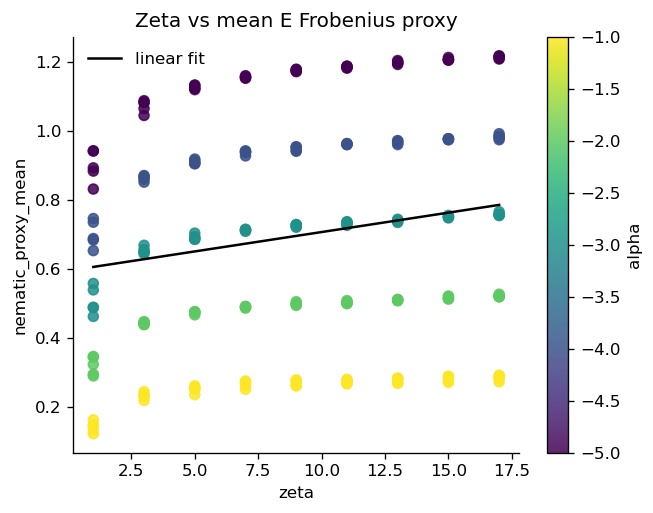

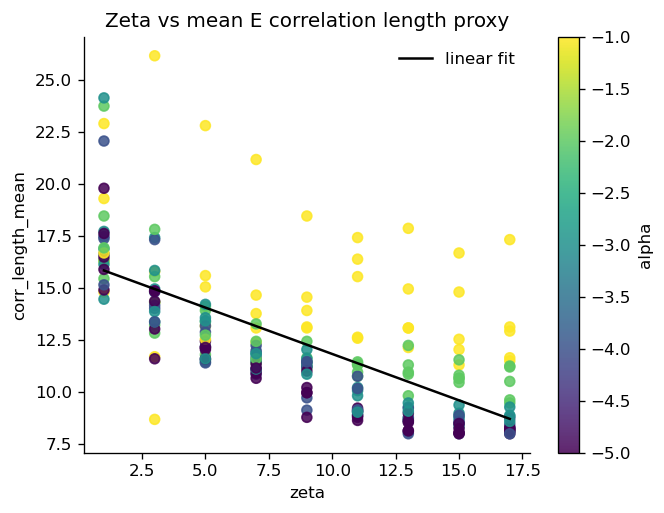

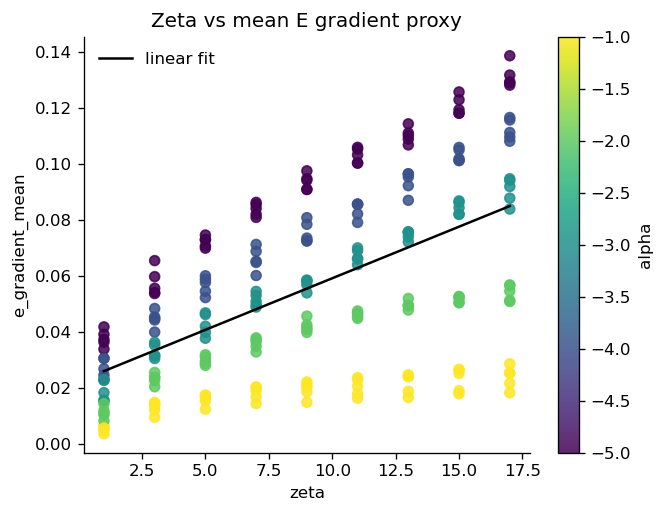

,pearson_r,pearson_p,spearman_r,spearman_p,linear_slope,linear_intercept,x,y
0,0.180768,6.550794e-03,0.248348,1.674768e-04,0.011231,0.595276,zeta,nematic_proxy_mean
1,-0.672645,5.387309e-31,-0.726865,2.981762e-38,-0.445794,16.294398,zeta,corr_length_mean
2,0.573165,4.780716e-21,0.557757,8.542641e-20,0.003690,0.022209,zeta,e_gradient_mean


In [11]:
def pearson_spearman(x: np.ndarray, y: np.ndarray) -> Dict[str, float]:
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 3:
        return {"pearson_r": np.nan, "pearson_p": np.nan, "spearman_r": np.nan, "spearman_p": np.nan}
    pr = stats.pearsonr(x[mask], y[mask])
    sr = stats.spearmanr(x[mask], y[mask])
    return {"pearson_r": float(pr.statistic), "pearson_p": float(pr.pvalue), "spearman_r": float(sr.statistic), "spearman_p": float(sr.pvalue)}


def scatter_with_fit(df: pd.DataFrame, xcol: str, ycol: str, out_path: Path, title: str) -> Dict[str, float]:
    x = df[xcol].to_numpy(float)
    y = df[ycol].to_numpy(float)
    c = df["alpha"].to_numpy(float)
    fig, ax = plt.subplots(figsize=(6, 4.5))
    sc = ax.scatter(x, y, c=c, s=35, alpha=0.85)
    finite = np.isfinite(x) & np.isfinite(y)
    if finite.sum() >= 2:
        slope, intercept = np.polyfit(x[finite], y[finite], deg=1)
        xs = np.linspace(x[finite].min(), x[finite].max(), 100)
        ax.plot(xs, slope * xs + intercept, color="black", linewidth=1.5, label="linear fit")
        ax.legend(frameon=False)
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.set_title(title)
    cb = fig.colorbar(sc, ax=ax)
    cb.set_label("alpha")
    fig.savefig(out_path, bbox_inches="tight")
    plt.show()
    out = pearson_spearman(x, y)
    if finite.sum() >= 2:
        out.update({"linear_slope": float(slope), "linear_intercept": float(intercept)})
    return out

summary_df = pd.read_csv(summary_csv)
correlation_rows = []
for ycol, title, filename in [
    ("nematic_proxy_mean", "Zeta vs mean E Frobenius proxy", "zeta_vs_nematic_proxy.png"),
    ("corr_length_mean", "Zeta vs mean E correlation length proxy", "zeta_vs_corr_length.png"),
    ("e_gradient_mean", "Zeta vs mean E gradient proxy", "zeta_vs_e_gradient.png"),
]:
    metrics = scatter_with_fit(summary_df, "zeta", ycol, FIGURES_DIR / filename, title)
    metrics.update({"x": "zeta", "y": ycol})
    correlation_rows.append(metrics)

correlation_df = pd.DataFrame(correlation_rows)
correlation_df.to_csv(TABLES_DIR / "zeta_metric_correlations.csv", index=False)
correlation_df

In [12]:
coarse_cols = [
    "concentration_mean", "concentration_std", "velocity_mag_mean", "velocity_mag_std",
    "nematic_proxy_mean", "corr_length_mean", "e_gradient_mean",
]
label_corr_rows = []
for label in ["alpha", "zeta"]:
    for col in coarse_cols:
        metrics = pearson_spearman(summary_df[label].to_numpy(float), summary_df[col].to_numpy(float))
        label_corr_rows.append({"label": label, "metric": col, **metrics})
label_corr_df = pd.DataFrame(label_corr_rows)
label_corr_df.to_csv(TABLES_DIR / "label_metric_correlations.csv", index=False)

label_corr_display_df = label_corr_df.copy()
label_corr_display_df["abs_spearman_r"] = label_corr_display_df["spearman_r"].abs()
label_corr_display_df.sort_values(
    ["label", "abs_spearman_r"],
    ascending=[True, False],
).drop(columns="abs_spearman_r")

,label,metric,pearson_r,pearson_p,spearman_r,spearman_p
4,alpha,nematic_proxy_mean,-0.973162,2.854357e-144,-0.961274,8.407692e-127
2,alpha,velocity_mag_mean,-0.918631,6.816396e-92,-0.935920,4.935397e-103
3,alpha,velocity_mag_std,-0.831196,9.014030e-59,-0.881583,1.192547e-74
6,alpha,e_gradient_mean,-0.766225,1.018918e-44,-0.779587,3.279670e-47
5,alpha,corr_length_mean,0.393971,8.999188e-10,0.446526,2.003353e-12
1,alpha,concentration_std,0.126218,5.871986e-02,0.140657,3.497994e-02
0,alpha,concentration_mean,-0.087917,1.888626e-01,-0.085552,2.010812e-01
12,zeta,corr_length_mean,-0.672645,5.387309e-31,-0.726865,2.981762e-38
13,zeta,e_gradient_mean,0.573165,4.780716e-21,0.557757,8.542641e-20
10,zeta,velocity_mag_std,-0.424649,2.896157e-11,-0.368163,1.248941e-08


## 9. Interpretation

This section generates a compact text summary from the saved scalar diagnostics. Treat it as a first-pass guide for deciding what to inspect next, not as a final scientific conclusion.

In [13]:
def strongest_abs_corr(corr_df: pd.DataFrame, label: str, metric_subset: Optional[Sequence[str]] = None) -> pd.Series:
    df = corr_df[corr_df["label"] == label].copy()
    if metric_subset is not None:
        df = df[df["metric"].isin(metric_subset)]
    df["abs_spearman"] = df["spearman_r"].abs()
    return df.sort_values("abs_spearman", ascending=False).iloc[0]

orientation_metrics = ["nematic_proxy_mean", "corr_length_mean", "e_gradient_mean"]
zeta_orientation = strongest_abs_corr(label_corr_df, "zeta", orientation_metrics)
alpha_coarse = strongest_abs_corr(label_corr_df, "alpha", ["concentration_mean", "concentration_std", "velocity_mag_mean", "velocity_mag_std"])
zeta_coarse = strongest_abs_corr(label_corr_df, "zeta", ["concentration_mean", "concentration_std", "velocity_mag_mean", "velocity_mag_std"])

text_summary = {
    "orientation_metrics_vary_with_zeta": bool(abs(zeta_orientation["spearman_r"]) >= 0.3),
    "strongest_zeta_orientation_metric": str(zeta_orientation["metric"]),
    "strongest_zeta_orientation_spearman": float(zeta_orientation["spearman_r"]),
    "strongest_alpha_coarse_metric": str(alpha_coarse["metric"]),
    "strongest_alpha_coarse_spearman": float(alpha_coarse["spearman_r"]),
    "strongest_zeta_coarse_metric": str(zeta_coarse["metric"]),
    "strongest_zeta_coarse_spearman": float(zeta_coarse["spearman_r"]),
    "supports_spatial_latents_later": bool(abs(zeta_orientation["spearman_r"]) >= abs(zeta_coarse["spearman_r"]) or abs(zeta_orientation["spearman_r"]) >= 0.3),
}
with open(OUTPUT_DIR / "interpretation_summary.json", "w") as f:
    json.dump(text_summary, f, indent=2)

print("Interpretation summary")
print(json.dumps(text_summary, indent=2))
print()
print("Questions")
print(f"- Do orientation-based metrics vary with zeta? strongest orientation Spearman is {text_summary['strongest_zeta_orientation_spearman']:.3f} for {text_summary['strongest_zeta_orientation_metric']}.")
print("- Do low-zeta and high-zeta regimes look visually different? inspect the saved representative field and director-overlay figures.")
print(f"- Does alpha appear easier from coarse scalar stats than zeta? alpha best coarse |rho|={abs(text_summary['strongest_alpha_coarse_spearman']):.3f}; zeta best coarse |rho|={abs(text_summary['strongest_zeta_coarse_spearman']):.3f}.")
print(f"- Does this support testing spatial latents later? {text_summary['supports_spatial_latents_later']}.")

Interpretation summary
{
  "orientation_metrics_vary_with_zeta": true,
  "strongest_zeta_orientation_metric": "corr_length_mean",
  "strongest_zeta_orientation_spearman": -0.7268653517398119,
  "strongest_alpha_coarse_metric": "velocity_mag_mean",
  "strongest_alpha_coarse_spearman": -0.9359199616187014,
  "strongest_zeta_coarse_metric": "velocity_mag_std",
  "strongest_zeta_coarse_spearman": -0.368163118785673,
  "supports_spatial_latents_later": true
}

Questions
- Do orientation-based metrics vary with zeta? strongest orientation Spearman is -0.727 for corr_length_mean.
- Do low-zeta and high-zeta regimes look visually different? inspect the saved representative field and director-overlay figures.
- Does alpha appear easier from coarse scalar stats than zeta? alpha best coarse |rho|=0.936; zeta best coarse |rho|=0.368.
- Does this support testing spatial latents later? True.


## 10. Lightweight Utilities for Later HPC Work

These utilities prepare split and window indexing logic only. They do not instantiate dataloaders, build models, train models, or run probes.

In [14]:
def grouped_split_by_file(metadata: pd.DataFrame, train_frac: float = 0.7, valid_frac: float = 0.15, seed: int = 42) -> pd.DataFrame:
    files = metadata[["file_path", "alpha", "zeta"]].drop_duplicates().reset_index(drop=True)
    rng = np.random.default_rng(seed)
    order = rng.permutation(len(files))
    n_train = int(round(train_frac * len(files)))
    n_valid = int(round(valid_frac * len(files)))
    split = np.array(["test"] * len(files), dtype=object)
    split[order[:n_train]] = "train"
    split[order[n_train:n_train + n_valid]] = "valid"
    out = files.copy()
    out["assigned_split"] = split
    return out


def build_chunk_window_indices(
    total_steps: int,
    context_chunk_len: int = CFG.context_chunk_len,
    target_chunk_len: int = CFG.target_chunk_len,
    future_gap: int = CFG.future_gap,
    frame_stride: int = CFG.frame_stride,
    start_stride: int = 1,
) -> List[Dict[str, List[int]]]:
    context_span = (context_chunk_len - 1) * frame_stride + 1
    target_span = (target_chunk_len - 1) * frame_stride + 1
    total_required = context_span + future_gap + target_span
    if total_steps < total_required:
        return []
    windows = []
    for start in range(0, total_steps - total_required + 1, start_stride):
        context = [start + i * frame_stride for i in range(context_chunk_len)]
        target_start = start + context_span + future_gap
        target = [target_start + i * frame_stride for i in range(target_chunk_len)]
        windows.append({"context": context, "target": target})
    return windows


def print_example_window_shapes(total_steps: int = 81, height: int = 256, width: int = 256, channels: int = 11) -> None:
    windows = build_chunk_window_indices(total_steps)
    print(f"num_windows={len(windows)} with context_chunk_len={CFG.context_chunk_len}, target_chunk_len={CFG.target_chunk_len}, future_gap={CFG.future_gap}, frame_stride={CFG.frame_stride}")
    if windows:
        print("first window:", windows[0])
    print(f"expected context tensor shape per trajectory window: ({channels}, {CFG.context_chunk_len}, {height}, {width})")
    print(f"expected target tensor shape per trajectory window:  ({channels}, {CFG.target_chunk_len}, {height}, {width})")

split_plan = grouped_split_by_file(metadata_df)
split_plan.to_csv(TABLES_DIR / "example_grouped_file_split.csv", index=False)
print_example_window_shapes()
split_plan.head()

num_windows=70 with context_chunk_len=4, target_chunk_len=4, future_gap=4, frame_stride=1
first window: {'context': [0, 1, 2, 3], 'target': [8, 9, 10, 11]}
expected context tensor shape per trajectory window: (11, 4, 256, 256)
expected target tensor shape per trajectory window:  (11, 4, 256, 256)


,file_path,alpha,zeta,assigned_split
0,data/train/active_matter_L_10.0_zeta_1.0_alpha...,-1.0,1.0,train
1,data/train/active_matter_L_10.0_zeta_1.0_alpha...,-2.0,1.0,train
2,data/train/active_matter_L_10.0_zeta_1.0_alpha...,-3.0,1.0,train
3,data/train/active_matter_L_10.0_zeta_1.0_alpha...,-4.0,1.0,train
4,data/train/active_matter_L_10.0_zeta_1.0_alpha...,-5.0,1.0,train


## 11. Collapse-Monitoring Helper Functions Only

These are tiny NumPy utilities for future embedding diagnostics. They are included here because later JEPA runs should monitor latent collapse, but this notebook does not train anything.

In [15]:
def latent_variance_stats(z: np.ndarray) -> Dict[str, float]:
    z = np.asarray(z, dtype=np.float64)
    if z.ndim != 2:
        raise ValueError(f"z must be [N,D], got {z.shape}")
    var = np.var(z, axis=0)
    return {
        "var_mean": float(np.mean(var)),
        "var_min": float(np.min(var)),
        "var_max": float(np.max(var)),
        "frac_near_zero": float(np.mean(var < 1e-8)),
    }


def latent_effective_rank(z: np.ndarray, eps: float = 1e-12) -> float:
    z = np.asarray(z, dtype=np.float64)
    if z.ndim != 2:
        raise ValueError(f"z must be [N,D], got {z.shape}")
    z = z - z.mean(axis=0, keepdims=True)
    s = np.linalg.svd(z, compute_uv=False)
    p = s / max(float(s.sum()), eps)
    entropy = -np.sum(p * np.log(p + eps))
    return float(np.exp(entropy))


def collapse_warning(z: np.ndarray, var_threshold: float = 1e-4, rank_fraction_threshold: float = 0.1) -> Dict[str, Any]:
    stats_dict = latent_variance_stats(z)
    erank = latent_effective_rank(z)
    dim = int(np.asarray(z).shape[1])
    warning = stats_dict["var_mean"] < var_threshold or erank < rank_fraction_threshold * dim
    return {**stats_dict, "effective_rank": erank, "dim": dim, "collapse_warning": bool(warning)}

In [16]:
rng = np.random.default_rng(0)
z_random = rng.normal(size=(128, 32))
z_collapsed = np.ones((128, 32))
z_partly_collapsed = np.concatenate([rng.normal(size=(128, 4)), np.zeros((128, 28))], axis=1)
print("random:", collapse_warning(z_random))
print("collapsed:", collapse_warning(z_collapsed))
print("partly collapsed:", collapse_warning(z_partly_collapsed))
assert not collapse_warning(z_random)["collapse_warning"]
assert collapse_warning(z_collapsed)["collapse_warning"]
assert collapse_warning(z_partly_collapsed)["collapse_warning"]
print("Collapse helper smoke tests passed.")

random: {'var_mean': 0.9861948043082459, 'var_min': 0.7973450229723132, 'var_max': 1.2826176586129059, 'frac_near_zero': 0.0, 'effective_rank': 30.916342787489956, 'dim': 32, 'collapse_warning': False}
collapsed: {'var_mean': 0.0, 'var_min': 0.0, 'var_max': 0.0, 'frac_near_zero': 1.0, 'effective_rank': 1.0, 'dim': 32, 'collapse_warning': True}
partly collapsed: {'var_mean': 0.1253753065639356, 'var_min': 0.0, 'var_max': 1.2312312532730145, 'frac_near_zero': 0.875, 'effective_rank': 3.9790585661224993, 'dim': 32, 'collapse_warning': False}


AssertionError: 

## 12. Local Safety Checklist

This notebook was designed to run top-to-bottom on CPU with laptop-scale memory:
- no training loop
- no PyTorch dependency
- no GPU dependency
- no full-dataset trajectory cache
- no multiprocessing
- one trajectory loaded at a time in the summary pass
- compact CSV/JSON summaries flushed to disk
- FFT autocorrelation computed per frame on downsampled scalar maps and immediately discarded

## 13. Final Notebook Conclusion

If the orientation proxy, spatial correlation-length proxy, or director overlays vary systematically with `zeta`, then `zeta` is plausibly tied to spatial organization in the orientation/alignment field rather than only coarse global intensity. That makes a later global-vs-spatial latent comparison scientifically justified: a global latent may capture average activity, while spatial latents may better preserve orientation texture, correlation length, and alignment domains.

The next HPC work should move from these no-training diagnostics to controlled JEPA pretraining comparisons under identical chunk-prediction objectives, followed by frozen linear and kNN regression on `alpha` and `zeta`.

In [ ]:
print("NEXT HPC STEP: train one global-latent JEPA and one spatial-latent JEPA under the same chunk-prediction objective, then evaluate frozen linear and kNN regression on alpha and zeta.")